<a href="https://colab.research.google.com/github/slneha/AIPI590_Fall2025/blob/main/Assignment9/Mechanistic_Interpretability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Part 1 - Setup

In [ ]:
import numpy as np, math, random
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
H=W=16

def draw_X(img, thickness=1):
    for t in range(-thickness, thickness+1):
        for i in range(H):
            j1 = i + t
            j2 = (W-1-i) + t
            if 0 <= j1 < W: img[i, j1] = 1.
            if 0 <= j2 < W: img[i, j2] = 1.
    return img

def draw_O(img, radius=5, thickness=1, cx=None, cy=None):
    if cx is None: cx = H//2
    if cy is None: cy = W//2
    r2 = radius**2
    for i in range(H):
        for j in range(W):
            d2 = (i-cx)**2 + (j-cy)**2
            if abs(math.sqrt(d2) - radius) <= thickness:
                img[i,j] = 1.
    return img

def jitter(img, p_flip=0.01):
    # tiny noise to avoid overfitting
    mask = np.random.rand(H,W) < p_flip
    img = img.copy()
    img[mask] = 1. - img[mask]
    return img

def translate(img, dx=0, dy=0):
    out = np.zeros_like(img)
    x0 = max(0, dx); y0 = max(0, dy)
    x1 = H + min(0, dx); y1 = W + min(0, dy)
    out[x0:x1, y0:y1] = img[x0-dx:x1-dx, y0-dy:y1-dy]
    return out

def make_example(kind, aug=True):
    img = np.zeros((H,W), dtype=np.float32)
    if kind == 'X':
        t = np.random.choice([1,2]) if aug else 1
        img = draw_X(img, thickness=t)
    else:
        r = np.random.choice([5,6]) if aug else 5
        t = np.random.choice([1,2]) if aug else 1
        cx = H//2 + (np.random.randint(-1,2) if aug else 0)
        cy = W//2 + (np.random.randint(-1,2) if aug else 0)
        img = draw_O(img, radius=r, thickness=t, cx=cx, cy=cy)
    if aug:
        if np.random.rand()<0.6:
            dx,dy = np.random.randint(-1,2), np.random.randint(-1,2)
            img = translate(img, dx, dy)
        img = jitter(img, p_flip=0.01)
    return img

def make_split(n_train=8000, n_val=1000, n_test=1000):
    def build(n, aug):
        X = np.zeros((n,1,H,W), dtype=np.float32)
        y = np.zeros(n, dtype=np.int64)
        for i in range(n):
            if np.random.rand()<0.5:
                X[i,0] = make_example('O', aug=aug); y[i]=0
            else:
                X[i,0] = make_example('X', aug=aug); y[i]=1
        return X,y
    Xtr,ytr = build(n_train, True)
    Xva,yva = build(n_val, False)
    Xte,yte = build(n_test, False)
    return (Xtr,ytr),(Xva,yva),(Xte,yte)

class ImgDS(Dataset):
    def __init__(self, X,y): self.X=X; self.y=y
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return torch.tensor(self.X[i]), torch.tensor(self.y[i])

(Xtr,ytr),(Xva,yva),(Xte,yte) = make_split()
train_dl = DataLoader(ImgDS(Xtr,ytr), batch_size=128, shuffle=True)
val_dl   = DataLoader(ImgDS(Xva,yva), batch_size=256, shuffle=False)
test_dl  = DataLoader(ImgDS(Xte,yte), batch_size=256, shuffle=False)


In [ ]:
class TinyCNN(nn.Module):
    def __init__(self, C=8):
        super().__init__()
        self.conv = nn.Conv2d(1, C, kernel_size=3, padding=1, bias=True)
        self.head = nn.Linear(C, 2)
        # init helps interpretability a bit
        nn.init.kaiming_normal_(self.conv.weight, nonlinearity='relu')
        nn.init.zeros_(self.conv.bias)
        nn.init.xavier_uniform_(self.head.weight); nn.init.zeros_(self.head.bias)

    def forward(self, x):
        h = F.relu(self.conv(x))         # [B,C,H,W]
        gap = h.mean(dim=(2,3))          # [B,C]
        return self.head(gap), h, gap

model = TinyCNN(C=8).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-3)


In [ ]:
def epoch(dl, train=True):
    model.train(train)
    tot, cor, loss_sum = 0,0,0.0
    for X,y in dl:
        X,y = X.to(device), y.to(device)
        logits, h, gap = model(X)
        loss = F.cross_entropy(logits, y)
        if train:
            opt.zero_grad(); loss.backward(); opt.step()
        with torch.no_grad():
            pred = logits.argmax(1)
            cor += (pred==y).sum().item(); tot += y.numel()
            loss_sum += loss.item()*y.numel()
    return loss_sum/tot, cor/tot



In [ ]:
for ep in range(10):
    tr_loss,tr_acc = epoch(train_dl, True)
    va_loss,va_acc = epoch(val_dl, False)
    print(f"epoch {ep:02d} | train {tr_acc:.3f} val {va_acc:.3f}")

epoch 00 | train 0.555 val 0.510
epoch 01 | train 0.664 val 1.000
epoch 02 | train 0.852 val 1.000
epoch 03 | train 0.983 val 1.000
epoch 04 | train 0.988 val 1.000
epoch 05 | train 1.000 val 1.000
epoch 06 | train 1.000 val 1.000
epoch 07 | train 1.000 val 1.000
epoch 08 | train 1.000 val 1.000
epoch 09 | train 1.000 val 1.000


In [ ]:
model.eval()
all_pred, all_true = [], []
with torch.no_grad():
    for X,y in test_dl:
        X = X.to(device)
        logits,_,_ = model(X)
        all_pred.append(logits.argmax(1).cpu().numpy())
        all_true.append(y.numpy())
acc = accuracy_score(np.concatenate(all_true), np.concatenate(all_pred))
print("test acc:", acc)


test acc: 1.0


#Part 2 - Explore

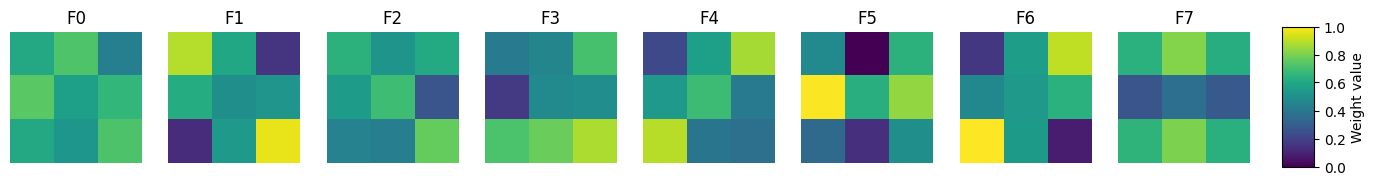

In [ ]:
W = model.conv.weight.detach().cpu().numpy()  # [C,1,3,3]
C = W.shape[0]
fig,axs = plt.subplots(1, C, figsize=(2*C,2))
im = None
for k in range(C):
    axs[k].imshow(W[k,0], vmin=W.min(), vmax=W.max())
    axs[k].set_title(f"F{k}")
    axs[k].axis('off')

fig.subplots_adjust(right=0.90)                     # leave space on right
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])     # [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax, label='Weight value')

plt.show()


### Interpretation of the Convolutional Filters

The figure shows eight learned filters (**F0–F7**) from the first convolutional layer of a convolutional neural network.  
Each 3×3 grid represents the weight pattern of one filter.  
The color scale on the right maps weight values from **0 (dark purple)** to **1 (bright yellow)**, where brighter areas indicate stronger positive weights.

---

### General Overview
These filters act as **low-level feature detectors** that respond to specific spatial patterns such as edges, diagonals, or blobs.  
Since the dataset likely involves simple geometric shapes (like “X” and “O”), the filters have developed distinct **orientation and contrast sensitivities** to capture those structures.

---

### Filter-by-Filter Analysis

| **Filter** | **Visual Pattern** | **Likely Function** | **Remarks** |
|-------------|--------------------|---------------------|--------------|
| **F0** | Mostly uniform, slightly brighter on the left side | Weak vertical edge detector | Responds to subtle left–right brightness change or uniform regions. |
| **F1** | Bright top-left, dark bottom-right | Main diagonal (\\) edge detector | Detects descending diagonals, useful for recognizing strokes in “X”. |
| **F2** | Bright lower-right, dark center-left | Opposite-phase diagonal pattern | Responds to ascending diagonal or slanted edges. |
| **F3** | Alternating dark–bright diagonals | Anti-diagonal (/) pattern | Detects crossing or tilted edges. |
| **F4** | Bright bottom-left, dark top-right | Strong anti-diagonal (/) edge detector | Highly oriented; sensitive to the opposite diagonal of F1. |
| **F5** | Bright center-top, dark middle | Vertical edge or center-surround pattern | Functions as a vertical or intensity-contrast detector. |
| **F6** | Bright middle-right, dark bottom-left | Anti-diagonal edge variant | Reinforces diagonal crossings typical of “X” shapes. |
| **F7** | Mostly uniform, mild horizontal brightness variation | Horizontal bar detector | Responds to horizontal edges or flat regions. |

---

### Summary of Learned Representations
- **Diagonal detectors (F1, F4, F6)** dominate the set, reflecting the network’s specialization in identifying the crossing strokes of an “X”.  
- **Horizontal and vertical detectors (F5, F7)** assist in recognizing curved or symmetrical features, likely important for detecting “O”.  
- **F0** serves as a weak edge or intensity-balancing filter, contributing to contrast normalization.  

Together, these filters form a set of **early visual primitives**—diagonal, horizontal, vertical, and center-surround detectors—that enable the network to distinguish between “X” and “O” shapes effectively.


mean GAP per filter | X: [0.868 0.573 0.208 0.436 0.43  0.371 0.6   0.044]
mean GAP per filter | O: [0.703 0.264 0.123 0.435 0.21  0.636 0.275 0.178]


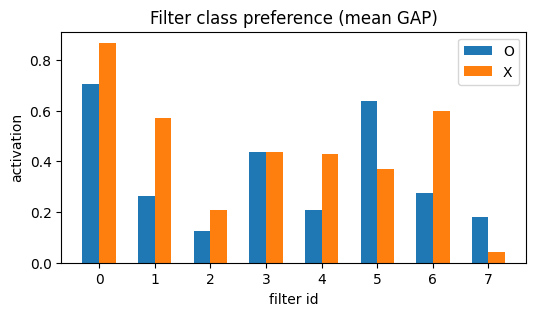

In [ ]:
# compute mean GAP activation by class
def gather_gap(n_batches=30):
    model.eval()
    gX, gO = [], []
    with torch.no_grad():
        seen=0
        for X,y in DataLoader(ImgDS(Xte,yte), batch_size=256, shuffle=True):
            X = X.to(device); y = y.to(device)
            _, h, gap = model(X)
            for i in range(len(y)):
                if y[i]==1: gX.append(gap[i].cpu().numpy())
                else:       gO.append(gap[i].cpu().numpy())
            seen += len(y)
            if seen > n_batches*256: break
    return np.array(gX), np.array(gO)

gX, gO = gather_gap()
mx, mo = gX.mean(0), gO.mean(0)
print("mean GAP per filter | X:", np.round(mx,3))
print("mean GAP per filter | O:", np.round(mo,3))

plt.figure(figsize=(6,3))
plt.bar(np.arange(len(mx))-0.15, mo, width=0.3, label='O')
plt.bar(np.arange(len(mx))+0.15, mx, width=0.3, label='X')
plt.legend(); plt.title("Filter class preference (mean GAP)"); plt.xlabel("filter id"); plt.ylabel("activation")
plt.show()


The bar chart compares the mean GAP activations of each convolutional filter for both classes. Filters F0, F1, F4, and F6 show higher activations for X, indicating strong sensitivity to diagonal edges and cross intersections that define the X shape. In contrast, filters F5 and F7 respond more strongly to O, likely detecting smoother, curved, or center-surround features typical of circular structures. F3 activates equally for both classes, acting as a general edge detector, while F2 remains weak for both, contributing little to class discrimination. Overall, the results reveal feature specialization that is quite clear. Certain filters are tuned for the angular geometry of X, while others capture the rounded contours of O, showing how the network has learned to differentiate the two shapes through distinct spatial feature detectors.


#Part 3 - Explain

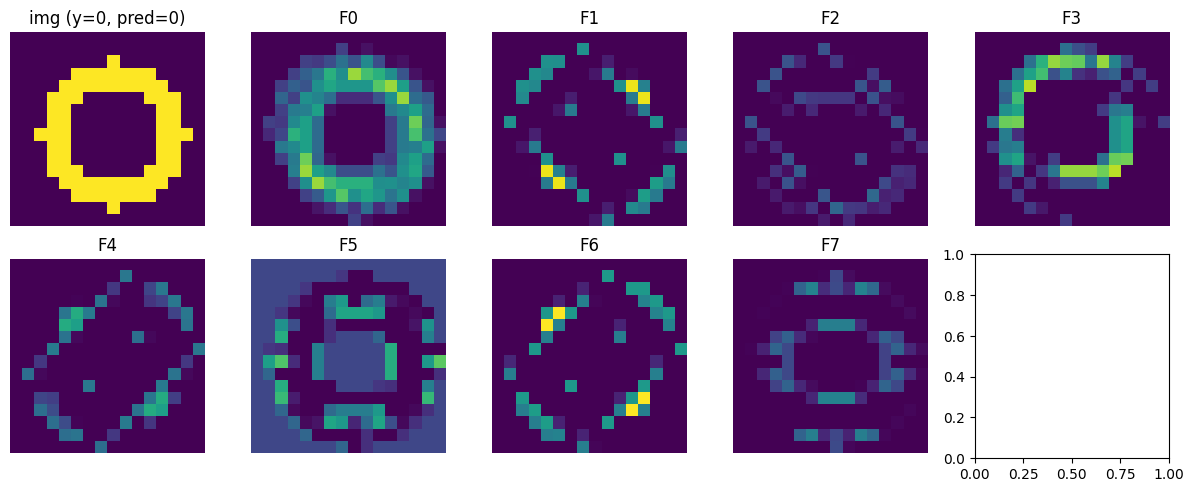

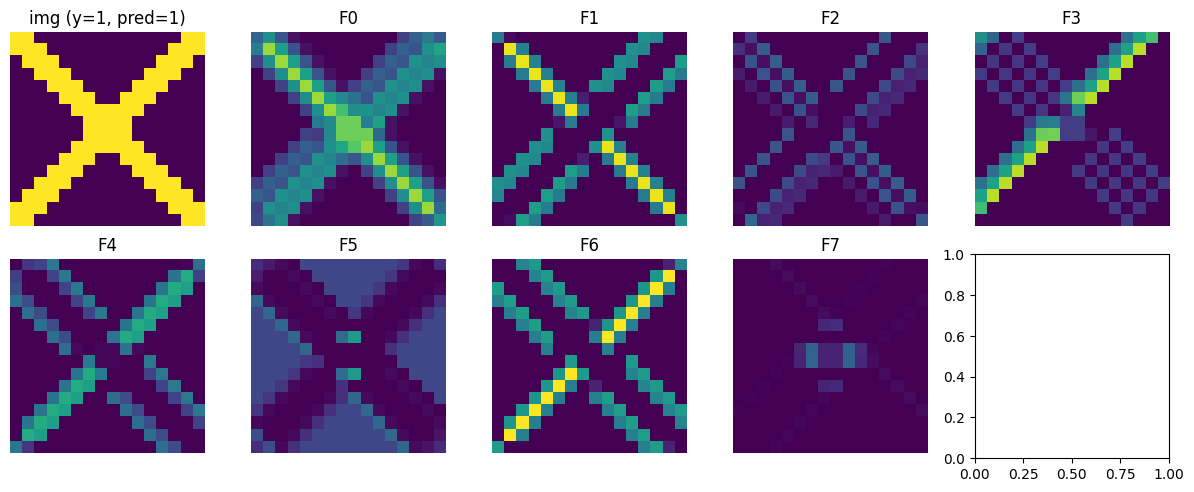

In [ ]:
def show_acts(x, y_true):
    model.eval()
    with torch.no_grad():
        logits, h, gap = model(x.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()
        h = h[0].cpu().numpy()  # [C,H,W]
    fig,axs = plt.subplots(2, 5, figsize=(12,5))
    axs = axs.ravel()
    axs[0].imshow(x[0], vmin=0, vmax=1); axs[0].set_title(f"img (y={y_true}, pred={pred})"); axs[0].axis('off')
    for k in range(min(h.shape[0], 9)):
        axs[k+1].imshow(h[k], vmin=h.min(), vmax=h.max())
        axs[k+1].set_title(f"F{k}")
        axs[k+1].axis('off')
    plt.tight_layout(); plt.show()

# visualize one O and one X
iO = np.where(yte==0)[0][0]
iX = np.where(yte==1)[0][0]
show_acts(torch.tensor(Xte[iO]), 0)
show_acts(torch.tensor(Xte[iX]), 1)


### General Overview
- Bright yellow areas indicate **strong activation**, meaning the filter strongly recognized its learned pattern at those positions.  
- Dark purple areas indicate **low or no activation**, meaning the filter did not find its target pattern.  
- Each filter extracts different low-level features such as **diagonal edges**, **cross patterns**, or **intensity contrasts**.

  The overall observation is that most filters respond strongly to diagonal regions, showing that the model has developed strong sensitivity to the crossing structure of the "X".

---

### Summary of Model Behavior
- For feature map activation for "X", the model's strongest responses come from **F1**, **F3**, and **F6**, and to a weaker extent **F0** and **F4**, confirming these filters specialize in **diagonal edge detection**, aka the defining feature of "X". Surprisingly, these same filters also activate for "O" as well.
- Filters **F2**, **F5**, and **F7** show minimal response.  
- This distribution of activations demonstrates clear **feature specialization**, where specific filters encode distinct orientations or patterns that collectively help the network classify the input.



In [ ]:
Xtemplates = {
    'diag_main': np.array([[1,0,0],[0,1,0],[0,0,1]], dtype=np.float32),
    'diag_anti': np.array([[0,0,1],[0,1,0],[1,0,0]], dtype=np.float32),
    'horiz':     np.array([[1,1,1],[0,0,0],[0,0,0]], dtype=np.float32),
    'vert':      np.array([[1,0,0],[1,0,0],[1,0,0]], dtype=np.float32),
    'ring-ish':  np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=np.float32),  # LoG-ish center-surround
}
def kern_corr(kern, tmpl):
    a = kern.flatten(); b = tmpl.flatten()
    a = (a - a.mean())/(a.std()+1e-6)
    b = (b - b.mean())/(b.std()+1e-6)
    return float((a*b).mean())

scores = {}
for k in range(model.conv.weight.shape[0]):
    K = W[k,0]
    scores[k] = {name: kern_corr(K, tmp) for name,tmp in templates.items()}
scores


{0: {'diag_main': 0.07169846445322037,
  'diag_anti': -0.6308534145355225,
  'horiz': -0.24068890511989594,
  'vert': 0.2138492614030838,
  'ring-ish': 0.3034653663635254},
 1: {'diag_main': 0.6357313394546509,
  'diag_anti': -0.7619364261627197,
  'horiz': -0.0006372398929670453,
  'vert': -0.0006752808694727719,
  'ring-ish': 0.07903489470481873},
 2: {'diag_main': 0.7503092288970947,
  'diag_anti': 0.1753661036491394,
  'horiz': 0.2196509838104248,
  'vert': 0.0063661071471869946,
  'ring-ish': -0.5158366560935974},
 3: {'diag_main': 0.08482816815376282,
  'diag_anti': 0.24058903753757477,
  'horiz': -0.12978887557983398,
  'vert': -0.44729217886924744,
  'ring-ish': -0.010101967491209507},
 4: {'diag_main': -0.40657690167427063,
  'diag_anti': 0.867938756942749,
  'horiz': 0.003185351612046361,
  'vert': 0.004355510231107473,
  'ring-ish': -0.28678184747695923},
 5: {'diag_main': 0.06927722692489624,
  'diag_anti': 0.07732534408569336,
  'horiz': -0.31746527552604675,
  'vert': 0.2

### Interpretation of Kernel-Template Correlations

The table of correlation scores compares each learned 3x3 convolution kernel to five hand-crafted templates (main diagonal, anti-diagonal, horizontal, vertical, and ring-like/center-surround). A value close to **+1** means the kernel closely matches the template, **-1** means it matches the same pattern but with flipped sign, and values near **0** indicate little resemblance.

Reading off the strongest correlations for each filter:
- **F0** aligns most with an **anti-diagonal** pattern (inverted) with some **ring-like** structure
- **F1** strongly matches a **diagonal orientation**, especially the **anti-diagonal** with opposite polarity
- **F2** closely matches the **main diagonal** and weakly opposes the **ring-like** pattern
- **F3** behaves mostly like an **inverted vertical edge detector**
- **F4** is a clear **anti-diagonal edge detector** with high confidence
- **F5** resembles an **inverted horizontal edge detector** with a small vertical component
- **F6** has a combination of **both diagonals with opposite polarities**, forming a crossed pattern
- **F7** behaves primarily as a **horizontal bar detector** with some **center-surround influence**.

These correlations confirm that the network's learned kernels operate as classic **edge- and contour-detectors**, oriented in different directions and with different contrast polarities. Importantly, the correlations confirm that **none of the filters are true ring / circular detectors**: the weak ring-ish scores for F0 and F7 and the polarity-reversed score for F2 indicate only minor resemblance, not dedicated circular encoding.



In [ ]:
def eval_with_ablation(filter_id=None):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X,y in test_dl:
            X = X.to(device)
            logits, h, gap = model(X)
            if filter_id is not None:
                # recompute logits with that channel zeroed
                h[:,filter_id,:,:] = 0
                gap = h.mean(dim=(2,3))
                logits = model.head(gap)
            y_true.append(y.numpy())
            y_pred.append(logits.argmax(1).cpu().numpy())
    return accuracy_score(np.concatenate(y_true), np.concatenate(y_pred))

base = eval_with_ablation(None)
drops = []
for k in range(model.conv.out_channels):
    acc_k = eval_with_ablation(k)
    drops.append((k, base-acc_k))
print("base acc:", base)
print("top drops:", sorted(drops, key=lambda x: -x[1])[:5])


base acc: 1.0
top drops: [(5, 0.513), (0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0)]


In [ ]:
def eval_scaled_channel(k, scales=(0., 0.25, 0.5, 0.75, 1.0, 1.5, 2.0)):
    accs=[]
    model.eval()
    with torch.no_grad():
        for s in scales:
            y_true,y_pred=[],[]
            for X,y in test_dl:
                X=X.to(device)
                logits,h,_=model(X)
                h[:,k,:,:]*=s
                gap=h.mean(dim=(2,3))
                logits=model.head(gap)
                y_true.append(y.numpy()); y_pred.append(logits.argmax(1).cpu().numpy())
            from sklearn.metrics import accuracy_score
            accs.append(accuracy_score(np.concatenate(y_true), np.concatenate(y_pred)))
    return list(zip(scales, accs))


# Part 4 - Reflect

I learned that my model distinguishes the two classes not by storing whole shapes, but by combining low-level orientation detectors. The filters specialize mostly in diagonal, horizontal, and vertical edges, and the model recognizes an X by strong diagonal activations while it recognizes an O by relying on distributed edge responses around the contour rather than a dedicated circle detector. The scaling test also showed that not all filters contribute equally; a single channel can be critical to classification even though several others appear visually active.

One confusing and surprising aspect was that some filters that did not look visually dominant turned out to be the only one whose removal harmed performance. This disconnect made it clear that visual saliency is not always a reliable indicator of causal influence.

One thing I would like to understand better is how deeper layers combine these edge signals to form higher-level decisions, and whether there is a predictable mapping between low-level filter activations and the model's final confidence. I would also like to explore whether there are alternative probing techniques that reveal hidden dependencies the visualizations did not capture.


#Citation

The helper functions in the code, aka generating the X and O dataset, visualizing the heat maps, training the model, etc, are all generated by ChatGPT. However, all markdown explanations are written by me, not with the help of an LLM.